In [1]:
!pip -q install ultralytics gdown yacs timm==0.9.16 motmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 13.2 MB/s eta 0:00:00


In [2]:
!rm -rf /kaggle/working/TransReID
!git clone --depth 1 https://github.com/damo-cv/TransReID.git /kaggle/working/TransReID

Cloning into '/kaggle/working/TransReID'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 112 (delta 45), reused 77 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 2.85 MiB | 14.33 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [3]:
import os
import torch
import subprocess

print("Notebook CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("torch.cuda.is_available():", torch.cuda.is_available())
print("torch.cuda.device_count():", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU 0:", torch.cuda.get_device_name(0))

print("\nSubprocess check:")
subprocess.run(
    [
        "python", "-c",
        "import os, torch; "
        "print('CUDA_VISIBLE_DEVICES=', os.environ.get('CUDA_VISIBLE_DEVICES')); "
        "print('cuda available=', torch.cuda.is_available()); "
        "print('device count=', torch.cuda.device_count()); "
        "print('name=', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU')"
    ],
    check=True
)

Notebook CUDA_VISIBLE_DEVICES: None
torch.cuda.is_available(): True
torch.cuda.device_count(): 2
GPU 0: Tesla T4

Subprocess check:
CUDA_VISIBLE_DEVICES= None
cuda available= True
device count= 2
name= Tesla T4


CompletedProcess(args=['python', '-c', "import os, torch; print('CUDA_VISIBLE_DEVICES=', os.environ.get('CUDA_VISIBLE_DEVICES')); print('cuda available=', torch.cuda.is_available()); print('device count=', torch.cuda.device_count()); print('name=', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU')"], returncode=0)

In [5]:
from pathlib import Path

repo = Path("/kaggle/working/TransReID")

# Patch 1: torch._six -> collections.abc
vp = repo / "model/backbones/vit_pytorch.py"
text = vp.read_text()
old = "from torch._six import container_abcs"
new = "import collections.abc as container_abcs"
if old in text and new not in text:
    vp.write_text(text.replace(old, new))

# Patch 2: save best_model.pth during validation on single-GPU training
pp = repo / "processor/processor.py"
text = pp.read_text()

if "best_mAP = -1.0" not in text:
    text = text.replace(
        "scaler = amp.GradScaler()\n    # train",
        "scaler = amp.GradScaler()\n    best_mAP = -1.0\n    best_epoch = -1\n    # train",
    )

    anchor = (
        '                logger.info("CMC curve, Rank-{:<3}:{:.1%}".format(r, cmc[r - 1]))\n'
        '                torch.cuda.empty_cache()'
    )

    replacement = (
        '                logger.info("CMC curve, Rank-{:<3}:{:.1%}".format(r, cmc[r - 1]))\n'
        '                if mAP > best_mAP:\n'
        '                    best_mAP = mAP\n'
        '                    best_epoch = epoch\n'
        '                    model_to_save = model.module if hasattr(model, "module") else model\n'
        '                    best_path = os.path.join(cfg.OUTPUT_DIR, "best_model.pth")\n'
        '                    torch.save(model_to_save.state_dict(), best_path)\n'
        '                    logger.info(f"Saved new best model to {best_path}")\n'
        '                    logger.info(f"Best so far - Epoch: {best_epoch}, mAP: {best_mAP:.1%}, Rank-1: {cmc[0]:.1%}")\n'
        '                torch.cuda.empty_cache()'
    )

    text = text.replace(anchor, replacement)
    pp.write_text(text)

print("Patched TransReID.")

Patched TransReID.


In [6]:
from pathlib import Path
import os
import shutil

def find_market_dir(base="/kaggle/input"):
    base = Path(base)
    for p in base.rglob("*"):
        if p.is_dir() and (p / "bounding_box_train").exists() and (p / "query").exists() and (p / "bounding_box_test").exists():
            return p
    return None

market_src = find_market_dir()

if market_src is None:
    raise FileNotFoundError(
        "Could not find Market-1501 under /kaggle/input.\n"
        "Add a Kaggle dataset that contains bounding_box_train, query, and bounding_box_test."
    )

data_root = Path("/kaggle/working/transreid_data")
data_root.mkdir(parents=True, exist_ok=True)

market_dst = data_root / "market1501"
if market_dst.exists() or market_dst.is_symlink():
    if market_dst.is_symlink() or market_dst.is_file():
        market_dst.unlink()
    else:
        shutil.rmtree(market_dst)

os.symlink(market_src, market_dst, target_is_directory=True)

print("Market source:", market_src)
print("Linked as    :", market_dst)
print("Train imgs   :", len(list((market_dst / "bounding_box_train").glob("*.jpg"))))

Market source: /kaggle/input/datasets/whurobin/market1501/Market-1501-v15.09.15
Linked as    : /kaggle/working/transreid_data/market1501
Train imgs   : 12936


In [7]:
from pathlib import Path
import urllib.request

PRETRAIN_DIR = Path("/kaggle/working/pretrained")
PRETRAIN_DIR.mkdir(parents=True, exist_ok=True)

IMAGENET_VIT = PRETRAIN_DIR / "jx_vit_base_p16_224-80ecf9dd.pth"
URL = "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-vitjx/jx_vit_base_p16_224-80ecf9dd.pth"

if not IMAGENET_VIT.exists():
    urllib.request.urlretrieve(URL, IMAGENET_VIT)

print(IMAGENET_VIT)

/kaggle/working/pretrained/jx_vit_base_p16_224-80ecf9dd.pth


In [8]:
from pathlib import Path

orig_cfg = Path("/kaggle/working/TransReID/configs/Market/vit_transreid_stride.yml")
kaggle_cfg = Path("/kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle.yml")

if not orig_cfg.exists():
    raise FileNotFoundError(f"Official config not found: {orig_cfg}")

text = orig_cfg.read_text()

# Force Kaggle GPU 0
text = text.replace("DEVICE_ID: ('5')", "DEVICE_ID: ('0')")

# Make output local to Kaggle working dir
text = text.replace(
    "OUTPUT_DIR: '../logs/market_vit_transreid_stride'",
    "OUTPUT_DIR: '/kaggle/working/transreid_market_t4'"
)

kaggle_cfg.write_text(text)

print("Created:", kaggle_cfg)
print(kaggle_cfg.read_text())

Created: /kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle.yml
MODEL:
  PRETRAIN_CHOICE: 'imagenet'
  PRETRAIN_PATH: '/home/heshuting/.cache/torch/checkpoints/jx_vit_base_p16_224-80ecf9dd.pth'
  METRIC_LOSS_TYPE: 'triplet'
  IF_LABELSMOOTH: 'off'
  IF_WITH_CENTER: 'no'
  NAME: 'transformer'
  NO_MARGIN: True
  DEVICE_ID: ('0')
  TRANSFORMER_TYPE: 'vit_base_patch16_224_TransReID'
  STRIDE_SIZE: [12, 12]
  SIE_CAMERA: True
  SIE_COE: 3.0
  JPM: True
  RE_ARRANGE: True

INPUT:
  SIZE_TRAIN: [256, 128]
  SIZE_TEST: [256, 128]
  PROB: 0.5 # random horizontal flip
  RE_PROB: 0.5 # random erasing
  PADDING: 10
  PIXEL_MEAN: [0.5, 0.5, 0.5]
  PIXEL_STD: [0.5, 0.5, 0.5]

DATASETS:
  NAMES: ('market1501')
  ROOT_DIR: ('../../data')

DATALOADER:
  SAMPLER: 'softmax_triplet'
  NUM_INSTANCE: 4
  NUM_WORKERS: 8

SOLVER:
  OPTIMIZER_NAME: 'SGD'
  MAX_EPOCHS: 120
  BASE_LR: 0.008
  IMS_PER_BATCH: 64
  WARMUP_METHOD: 'linear'
  LARGE_FC_LR: False
  CHECKPOINT_PERIOD: 120
  LOG_PERIOD

In [22]:
from pathlib import Path

RUN_NAME = "transreid_market_stride_30ep"
OUTPUT_DIR = f"/kaggle/working/{RUN_NAME}"

MAX_EPOCHS = 120
CKPT_PERIOD = 40
EVAL_PERIOD = 20
LOG_PERIOD = 20

# Stable single-GPU defaults
TRAIN_BATCH_1GPU = 16
TEST_BATCH_1GPU = 64
BASE_LR_1GPU = 0.002

# Optional 2-GPU defaults
TRAIN_BATCH_2GPU = 32   # total batch across both GPUs
TEST_BATCH_2GPU = 128
BASE_LR_2GPU = 0.004

repo = Path("/kaggle/working/TransReID")
base_cfg = repo / "configs/Market/vit_transreid_stride_kaggle.yml"
runtime_cfg = repo / "configs/Market/vit_transreid_stride_kaggle_runtime.yml"

text = base_cfg.read_text()
text = text.replace("OUTPUT_DIR: '/kaggle/working/transreid_market_t4'", f"OUTPUT_DIR: '{OUTPUT_DIR}'")
runtime_cfg.write_text(text)

print("Runtime config:", runtime_cfg)
print("Output dir    :", OUTPUT_DIR)
print(runtime_cfg.read_text())

Runtime config: /kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle_runtime.yml
Output dir    : /kaggle/working/transreid_market_stride_30ep
MODEL:
  PRETRAIN_CHOICE: 'imagenet'
  PRETRAIN_PATH: '/home/heshuting/.cache/torch/checkpoints/jx_vit_base_p16_224-80ecf9dd.pth'
  METRIC_LOSS_TYPE: 'triplet'
  IF_LABELSMOOTH: 'off'
  IF_WITH_CENTER: 'no'
  NAME: 'transformer'
  NO_MARGIN: True
  DEVICE_ID: ('0')
  TRANSFORMER_TYPE: 'vit_base_patch16_224_TransReID'
  STRIDE_SIZE: [12, 12]
  SIE_CAMERA: True
  SIE_COE: 3.0
  JPM: True
  RE_ARRANGE: True

INPUT:
  SIZE_TRAIN: [256, 128]
  SIZE_TEST: [256, 128]
  PROB: 0.5 # random horizontal flip
  RE_PROB: 0.5 # random erasing
  PADDING: 10
  PIXEL_MEAN: [0.5, 0.5, 0.5]
  PIXEL_STD: [0.5, 0.5, 0.5]

DATASETS:
  NAMES: ('market1501')
  ROOT_DIR: ('../../data')

DATALOADER:
  SAMPLER: 'softmax_triplet'
  NUM_INSTANCE: 4
  NUM_WORKERS: 8

SOLVER:
  OPTIMIZER_NAME: 'SGD'
  MAX_EPOCHS: 120
  BASE_LR: 0.008
  IMS_PER_BATCH: 64
  WARMUP

In [16]:
from pathlib import Path

tp = Path("/kaggle/working/TransReID/train.py")
text = tp.read_text()

# Patch A: allow torchrun to pass LOCAL_RANK
old_args = "    args = parser.parse_args()\n"
new_args = (
    "    args = parser.parse_args()\n"
    "    if 'LOCAL_RANK' in os.environ:\n"
    "        args.local_rank = int(os.environ['LOCAL_RANK'])\n"
)

if old_args in text and "if 'LOCAL_RANK' in os.environ:" not in text:
    text = text.replace(old_args, new_args, 1)

# Patch B: do not overwrite CUDA_VISIBLE_DEVICES during DDP
old_cuda = "    os.environ['CUDA_VISIBLE_DEVICES'] = cfg.MODEL.DEVICE_ID\n"
new_cuda = (
    "    if not cfg.MODEL.DIST_TRAIN:\n"
    "        os.environ['CUDA_VISIBLE_DEVICES'] = cfg.MODEL.DEVICE_ID\n"
)

if old_cuda in text and "if not cfg.MODEL.DIST_TRAIN:" not in text:
    text = text.replace(old_cuda, new_cuda, 1)

tp.write_text(text)
print("Patched train.py successfully.")

Patched train.py successfully.


In [17]:
from pathlib import Path

pp = Path("/kaggle/working/TransReID/processor/processor.py")
text = pp.read_text()

if "import torch.distributed as dist" not in text:
    text = text.replace(
        "import torch\n",
        "import torch\nimport torch.distributed as dist\n",
        1
    )

if "best_mAP = -1.0" not in text:
    text = text.replace(
        "    scaler = amp.GradScaler()\n",
        "    scaler = amp.GradScaler()\n    best_mAP = -1.0\n    best_epoch = -1\n",
        1
    )

old_block = """                logger.info("CMC curve, Rank-{:<3}:{:.1%}".format(r, cmc[r - 1]))
                torch.cuda.empty_cache()"""

new_block = """                logger.info("CMC curve, Rank-{:<3}:{:.1%}".format(r, cmc[r - 1]))
                is_main_process = (not cfg.MODEL.DIST_TRAIN) or (not dist.is_available()) or (not dist.is_initialized()) or dist.get_rank() == 0
                if mAP > best_mAP:
                    best_mAP = mAP
                    best_epoch = epoch
                    if is_main_process:
                        model_to_save = model.module if hasattr(model, "module") else model
                        best_path = os.path.join(cfg.OUTPUT_DIR, "best_model.pth")
                        torch.save(model_to_save.state_dict(), best_path)
                        logger.info(f"Saved new best model to {best_path}")
                    logger.info(f"Best so far - Epoch: {best_epoch}, mAP: {best_mAP:.1%}, Rank-1: {cmc[0]:.1%}")
                torch.cuda.empty_cache()"""

if old_block in text and "Saved new best model to" not in text:
    text = text.replace(old_block, new_block, 1)

pp.write_text(text)
print("Patched processor.py successfully.")

Patched processor.py successfully.


In [18]:
from pathlib import Path

tp = Path("/kaggle/working/TransReID/train.py")
lines = tp.read_text().splitlines()

print("=== train.py relevant lines ===")
for i, line in enumerate(lines, start=1):
    if 25 <= i <= 55:
        print(f"{i:03d}: {line}")

=== train.py relevant lines ===
025: if __name__ == '__main__':
026: 
027:     parser = argparse.ArgumentParser(description="ReID Baseline Training")
028:     parser.add_argument(
029:         "--config_file", default="", help="path to config file", type=str
030:     )
031: 
032:     parser.add_argument("opts", help="Modify config options using the command-line", default=None,
033:                         nargs=argparse.REMAINDER)
034:     parser.add_argument("--local_rank", default=0, type=int)
035:     args = parser.parse_args()
036:     if 'LOCAL_RANK' in os.environ:
037:         args.local_rank = int(os.environ['LOCAL_RANK'])
038: 
039:     if args.config_file != "":
040:         cfg.merge_from_file(args.config_file)
041:     cfg.merge_from_list(args.opts)
042:     cfg.freeze()
043: 
044:     set_seed(cfg.SOLVER.SEED)
045: 
046:     if cfg.MODEL.DIST_TRAIN:
047:         torch.cuda.set_device(args.local_rank)
048: 
049:     output_dir = cfg.OUTPUT_DIR
050:     if output_dir and not 

In [19]:
from pathlib import Path

print("=== train.py checks ===")
t = Path("/kaggle/working/TransReID/train.py").read_text()
print("LOCAL_RANK patch:", "if 'LOCAL_RANK' in os.environ:" in t)
print("DDP CUDA_VISIBLE_DEVICES patch:", "if not cfg.MODEL.DIST_TRAIN:" in t)

print("\n=== processor.py checks ===")
p = Path("/kaggle/working/TransReID/processor/processor.py").read_text()
print("dist import patch:", "import torch.distributed as dist" in p)
print("best model patch:", "Saved new best model to" in p)

=== train.py checks ===
LOCAL_RANK patch: True
DDP CUDA_VISIBLE_DEVICES patch: True

=== processor.py checks ===
dist import patch: True
best model patch: True


In [20]:
import torch
import subprocess

print("Notebook CUDA:", torch.cuda.is_available(), "count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

subprocess.run(["torchrun", "--help"], check=True, stdout=subprocess.DEVNULL)
print("torchrun OK")

Notebook CUDA: True count: 2
0 Tesla T4
1 Tesla T4
torchrun OK


In [23]:
import os
import subprocess
from pathlib import Path

env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = "0,1"

cmd = [
    "torchrun",
    "--nproc_per_node=2",
    "--master_port=29501",
    "train.py",
    "--config_file", str(runtime_cfg),
    "MODEL.DIST_TRAIN", "True",
    "MODEL.DEVICE_ID", "('0')",
    "MODEL.PRETRAIN_PATH", str(Path("/kaggle/working/pretrained/jx_vit_base_p16_224-80ecf9dd.pth")),
    "DATASETS.ROOT_DIR", "/kaggle/working/transreid_data",
    "OUTPUT_DIR", OUTPUT_DIR,
    "DATALOADER.NUM_WORKERS", "2",
    "SOLVER.IMS_PER_BATCH", str(TRAIN_BATCH_2GPU),
    "SOLVER.BASE_LR", str(BASE_LR_2GPU),
    "SOLVER.MAX_EPOCHS", str(MAX_EPOCHS),
    "SOLVER.CHECKPOINT_PERIOD", str(CKPT_PERIOD),
    "SOLVER.EVAL_PERIOD", str(EVAL_PERIOD),
    "SOLVER.LOG_PERIOD", str(LOG_PERIOD),
    "TEST.IMS_PER_BATCH", str(TEST_BATCH_2GPU),
    "TEST.EVAL", "True",
]

print("Running:\n", " ".join(cmd))
subprocess.run(cmd, cwd=str(repo), env=env, check=True)

Running:
 torchrun --nproc_per_node=2 --master_port=29501 train.py --config_file /kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle_runtime.yml MODEL.DIST_TRAIN True MODEL.DEVICE_ID ('0') MODEL.PRETRAIN_PATH /kaggle/working/pretrained/jx_vit_base_p16_224-80ecf9dd.pth DATASETS.ROOT_DIR /kaggle/working/transreid_data OUTPUT_DIR /kaggle/working/transreid_market_stride_30ep DATALOADER.NUM_WORKERS 2 SOLVER.IMS_PER_BATCH 32 SOLVER.BASE_LR 0.004 SOLVER.MAX_EPOCHS 120 SOLVER.CHECKPOINT_PERIOD 40 SOLVER.EVAL_PERIOD 20 SOLVER.LOG_PERIOD 20 TEST.IMS_PER_BATCH 128 TEST.EVAL True


W0419 16:58:33.974000 297 torch/distributed/run.py:852] 
W0419 16:58:33.974000 297 torch/distributed/run.py:852] *****************************************
W0419 16:58:33.974000 297 torch/distributed/run.py:852] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0419 16:58:33.974000 297 torch/distributed/run.py:852] *****************************************


2026-04-19 16:58:39,198 transreid INFO: Saving model in the path :/kaggle/working/transreid_market_stride_30ep
2026-04-19 16:58:39,198 transreid INFO: Namespace(config_file='/kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle_runtime.yml', opts=['MODEL.DIST_TRAIN', 'True', 'MODEL.DEVICE_ID', "('0')", 'MODEL.PRETRAIN_PATH', '/kaggle/working/pretrained/jx_vit_base_p16_224-80ecf9dd.pth', 'DATASETS.ROOT_DIR', '/kaggle/working/transreid_data', 'OUTPUT_DIR', '/kaggle/working/transreid_market_stride_30ep', 'DATALOADER.NUM_WORKERS', '2', 'SOLVER.IMS_PER_BATCH', '32', 'SOLVER.BASE_LR', '0.004', 'SOLVER.MAX_EPOCHS', '120', 'SOLVER.CHECKPOINT_PERIOD', '40', 'SOLVER.EVAL_PERIOD', '20', 'SOLVER.LOG_PERIOD', '20', 'TEST.IMS_PER_BATCH', '128', 'TEST.EVAL', 'True'], local_rank=0)
2026-04-19 16:58:39,198 transreid INFO: Loaded configuration file /kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle_runtime.yml
2026-04-19 16:58:39,199 transreid INFO: 
MODEL:
  PRETRAIN_CH

/kaggle/working/TransReID/processor/processor.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/kaggle/working/TransReID/processor/processor.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/kaggle/working/TransReID/datasets/sampler_ddp.py:34: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage = torch.ByteStorage.from_buffer(buffer)
/kaggle/working/TransReID/datasets/sampler_ddp.py:34: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only

[Gloo] Rank [Gloo] Rank 0 is connected to 11 is connected to  peer ranks. Expected number of connected peer ranks is : 11 peer ranks. 
Expected number of connected peer ranks is : 1


...

2026-04-19 16:58:48,225 transreid.train INFO: Epoch[1] Iteration[20/370] Loss: 10.600, Acc: 0.000, Base Lr: 8.32e-04
2026-04-19 16:58:48,225 transreid.train INFO: Epoch[1] Iteration[20/370] Loss: 10.130, Acc: 0.000, Base Lr: 8.32e-04
2026-04-19 16:58:53,132 transreid.train INFO: Epoch[1] Iteration[40/370] Loss: 9.541, Acc: 0.002, Base Lr: 8.32e-04
2026-04-19 16:58:53,133 transreid.train INFO: Epoch[1] Iteration[40/370] Loss: 9.398, Acc: 0.002, Base Lr: 8.32e-04
2026-04-19 16:58:58,071 transreid.train INFO: Epoch[1] Iteration[60/370] Loss: 8.970, Acc: 0.004, Base Lr: 8.32e-04
2026-04-19 16:58:58,071 transreid.train INFO: Epoch[1] Iteration[60/370] Loss: 8.989, Acc: 0.005, Base Lr: 8.32e-04
2026-04-19 16:59:02,989 transreid.train INFO: Epoch[1] Iteration[80/370] Loss: 8.703, Acc: 0.006, Base Lr: 8.32e-04
2026-04-19 16:59:02,989 transreid.train INFO: Epoch[1] Iteration[80/370] Loss: 8.707, Acc: 0.013, Base Lr: 8.32e-04
2026-04-19 16:59:07,950 transreid.train INFO: Epoch[1] Iteration[100/3

/kaggle/working/TransReID/utils/metrics.py:12: UserWarning: This overload of addmm_ is deprecated:
	addmm_(Number beta, Number alpha, Tensor mat1, Tensor mat2)
Consider using one of the following signatures instead:
	addmm_(Tensor mat1, Tensor mat2, *, Number beta = 1, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1862.)
  dist_mat.addmm_(1, -2, qf, gf.t())


2026-04-19 17:34:11,897 transreid.train INFO: Validation Results - Epoch: 20
2026-04-19 17:34:11,897 transreid.train INFO: mAP: 84.5%
2026-04-19 17:34:11,897 transreid.train INFO: CMC curve, Rank-1  :93.2%
2026-04-19 17:34:11,898 transreid.train INFO: CMC curve, Rank-5  :97.6%
2026-04-19 17:34:11,898 transreid.train INFO: CMC curve, Rank-10 :98.5%
[Gloo] Rank 1 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
[Gloo] Rank 0 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
2026-04-19 17:34:17,265 transreid.train INFO: Epoch[21] Iteration[20/370] Loss: 1.091, Acc: 0.894, Base Lr: 3.71e-03
2026-04-19 17:34:17,265 transreid.train INFO: Epoch[21] Iteration[20/370] Loss: 1.209, Acc: 0.903, Base Lr: 3.71e-03
2026-04-19 17:34:22,267 transreid.train INFO: Epoch[21] Iteration[40/370] Loss: 1.177, Acc: 0.898, Base Lr: 3.71e-03
2026-04-19 17:34:22,267 transreid.train INFO: Epoch[21] Iteration[40/370] Loss: 1.147, Acc: 0.898, Base Lr: 3.71e-03


[rank0]:[W419 20:33:54.423431355 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


CompletedProcess(args=['torchrun', '--nproc_per_node=2', '--master_port=29501', 'train.py', '--config_file', '/kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle_runtime.yml', 'MODEL.DIST_TRAIN', 'True', 'MODEL.DEVICE_ID', "('0')", 'MODEL.PRETRAIN_PATH', '/kaggle/working/pretrained/jx_vit_base_p16_224-80ecf9dd.pth', 'DATASETS.ROOT_DIR', '/kaggle/working/transreid_data', 'OUTPUT_DIR', '/kaggle/working/transreid_market_stride_30ep', 'DATALOADER.NUM_WORKERS', '2', 'SOLVER.IMS_PER_BATCH', '32', 'SOLVER.BASE_LR', '0.004', 'SOLVER.MAX_EPOCHS', '120', 'SOLVER.CHECKPOINT_PERIOD', '40', 'SOLVER.EVAL_PERIOD', '20', 'SOLVER.LOG_PERIOD', '20', 'TEST.IMS_PER_BATCH', '128', 'TEST.EVAL', 'True'], returncode=0)

In [15]:
!git -C /kaggle/working/TransReID checkout -- train.py processor/processor.py

In [24]:
from pathlib import Path
import os
import sys
import cv2
import numpy as np
import pandas as pd
import torch
import motmetrics as mm

from ultralytics import YOLO
import ultralytics.trackers.bot_sort as ubotsort

# -----------------------------
# EDIT THESE PATHS
# -----------------------------
# Example:
# MOT17_TRAIN_ROOT = Path("/kaggle/input/mot17/MOT17/train")
# MOT20_TRAIN_ROOT = Path("/kaggle/input/mot20/MOT20/train")

MOT17_TRAIN_ROOT = Path("/kaggle/input/datasets/wenhoujinjust/mot-17/MOT17/train")
MOT20_TRAIN_ROOT = Path("/kaggle/input/datasets/ismailelbouknify/mot-20/MOT20/train")

# If your MOT17 dataset contains all variants, keep only one family for fair evaluation.
# Use "FRCNN" or None.
MOT17_SUFFIX_FILTER = "FRCNN"

# Output folder
RUN_ROOT = Path("/kaggle/working/eval_botsort_transreid")
RUN_ROOT.mkdir(parents=True, exist_ok=True)

# YOLO detector
YOLO_WEIGHTS = "yolov8x.pt"

# Trained TransReID experiment folder
TRANSREID_EXP_DIR = Path("/kaggle/working/transreid_market_stride_30ep")

# Pick checkpoint automatically
weight_candidates = [
    TRANSREID_EXP_DIR / "best_model.pth",
    TRANSREID_EXP_DIR / "transformer_120.pth",
    TRANSREID_EXP_DIR / "transformer_80.pth",
    TRANSREID_EXP_DIR / "transformer_40.pth",
]

TRANSREID_WEIGHT = next((p for p in weight_candidates if p.exists()), None)
if TRANSREID_WEIGHT is None:
    raise FileNotFoundError(f"No TransReID checkpoint found in {TRANSREID_EXP_DIR}")

# Prefer runtime config if it exists
cfg_candidates = [
    Path("/kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle_runtime.yml"),
    Path("/kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle.yml"),
    Path("/kaggle/working/TransReID/configs/Market/vit_transreid_stride.yml"),
]

TRANSREID_CONFIG = next((p for p in cfg_candidates if p.exists()), None)
if TRANSREID_CONFIG is None:
    raise FileNotFoundError("Could not find a TransReID config file in /kaggle/working/TransReID/configs/Market/")

print("MOT17 root       :", MOT17_TRAIN_ROOT)
print("MOT20 root       :", MOT20_TRAIN_ROOT)
print("TransReID weight :", TRANSREID_WEIGHT)
print("TransReID config :", TRANSREID_CONFIG)
print("Run root         :", RUN_ROOT)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 263ms
Prepared 1 package in 90ms
Installed 1 package in 3ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

MOT17 root       : /kaggle/input/datasets/wenhoujinjust/mot-17/MOT17/train
MOT20 root       : /kaggle/input/datasets/ismailelbouknify/mot-20/MOT20/train
TransReID weight : /kaggle/working/transreid_market_stride_30ep/transformer_120.pth
TransReID config : /kaggle/working/TransReID/configs/Market/vit_transreid_stride_kaggle_runtime

In [25]:
TRANSREID_REPO = Path("/kaggle/working/TransReID")
if not TRANSREID_REPO.exists():
    raise FileNotFoundError("TransReID repo not found at /kaggle/working/TransReID")

if str(TRANSREID_REPO) not in sys.path:
    sys.path.insert(0, str(TRANSREID_REPO))

from config import cfg as tr_cfg
from model import make_model as tr_make_model

print("TransReID repo loaded from:", TRANSREID_REPO)

TransReID repo loaded from: /kaggle/working/TransReID


In [26]:
class TransReIDEncoder:
    """
    Ultralytics BoT-SORT expects:
        encoder(img_bgr, dets_xywh_plus_idx) -> list[np.ndarray]
    """
    def __init__(self, model_path: str):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        cfg = tr_cfg.clone()
        cfg.defrost()
        cfg.merge_from_file(str(TRANSREID_CONFIG))
        cfg.MODEL.PRETRAIN_CHOICE = "self"
        cfg.TEST.WEIGHT = str(model_path)
        cfg.TEST.NECK_FEAT = "before"
        cfg.TEST.FEAT_NORM = "yes"
        cfg.freeze()
        self.cfg = cfg

        # Market-1501 setup used during training
        self.model = tr_make_model(self.cfg, num_class=751, camera_num=6, view_num=1)
        self.model.load_param(str(model_path))
        self.model.to(self.device).eval()

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 256, 128, device=self.device)
            cam = torch.zeros(1, dtype=torch.long, device=self.device)
            view = torch.zeros(1, dtype=torch.long, device=self.device)
            feat = self.model(dummy, cam_label=cam, view_label=view)
            feat = torch.nn.functional.normalize(feat, dim=1)
        self.feat_dim = int(feat.shape[1])

    @staticmethod
    def _clip_box(x1: int, y1: int, x2: int, y2: int, w: int, h: int):
        x1 = max(0, min(x1, w))
        y1 = max(0, min(y1, h))
        x2 = max(0, min(x2, w))
        y2 = max(0, min(y2, h))
        return x1, y1, x2, y2

    def _preprocess(self, crop_bgr: np.ndarray) -> torch.Tensor:
        crop = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        crop = cv2.resize(crop, (128, 256), interpolation=cv2.INTER_LINEAR)
        x = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
        x = (x - 0.5) / 0.5
        return x

    def __call__(self, img: np.ndarray, dets: np.ndarray):
        if dets is None or len(dets) == 0:
            return []

        h, w = img.shape[:2]
        features = [None] * len(dets)
        batch = []
        valid_idx = []

        for i, det in enumerate(dets):
            cx, cy, bw, bh = det[:4]

            x1 = int(round(cx - bw / 2))
            y1 = int(round(cy - bh / 2))
            x2 = int(round(cx + bw / 2))
            y2 = int(round(cy + bh / 2))
            x1, y1, x2, y2 = self._clip_box(x1, y1, x2, y2, w, h)

            if x2 <= x1 or y2 <= y1:
                features[i] = np.zeros(self.feat_dim, dtype=np.float32)
                continue

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                features[i] = np.zeros(self.feat_dim, dtype=np.float32)
                continue

            batch.append(self._preprocess(crop))
            valid_idx.append(i)

        if batch:
            x = torch.stack(batch).to(self.device, non_blocking=True)
            cam = torch.zeros(x.size(0), dtype=torch.long, device=self.device)
            view = torch.zeros(x.size(0), dtype=torch.long, device=self.device)

            with torch.no_grad():
                feat = self.model(x, cam_label=cam, view_label=view)
                feat = torch.nn.functional.normalize(feat, dim=1)

            feat = feat.detach().cpu().numpy().astype(np.float32)
            for idx, emb in zip(valid_idx, feat):
                features[idx] = emb

        return features

In [27]:
enc = TransReIDEncoder(str(TRANSREID_WEIGHT))

dummy_img = np.zeros((720, 1280, 3), dtype=np.uint8)
dummy_dets = np.array([
    [200, 300, 80, 160, 0],
    [500, 320, 90, 180, 1],
], dtype=np.float32)

dummy_feats = enc(dummy_img, dummy_dets)
print("Number of features:", len(dummy_feats))
print("Feature shape     :", dummy_feats[0].shape)
print("L2 norm           :", np.linalg.norm(dummy_feats[0]))

using Transformer_type: vit_base_patch16_224_TransReID as a backbone
using stride: [12, 12], and patch number is num_y21 * num_x10
camera number is : 6
using SIE_Lambda is : 3.0
using drop_out rate is : 0.0
using attn_drop_out rate is : 0.0
using drop_path rate is : 0.1
using shuffle_groups size:2
using shift_num size:5
using divide_length size:4
===========building transformer with JPM module ===========
Loading pretrained model from /kaggle/working/transreid_market_stride_30ep/transformer_120.pth
Number of features: 2
Feature shape     : (3840,)
L2 norm           : 1.0


In [28]:
# Replace Ultralytics default ReID class with our TransReID wrapper
ubotsort.ReID = TransReIDEncoder

TRACKER_YAML = RUN_ROOT / "botsort_transreid.yaml"
TRACKER_YAML.write_text(
f"""tracker_type: botsort
track_high_thresh: 0.25
track_low_thresh: 0.10
new_track_thresh: 0.25
track_buffer: 30
match_thresh: 0.80
fuse_score: True
gmc_method: sparseOptFlow
proximity_thresh: 0.50
appearance_thresh: 0.80
with_reid: True
model: {TRANSREID_WEIGHT}
"""
)

print(TRACKER_YAML.read_text())

tracker_type: botsort
track_high_thresh: 0.25
track_low_thresh: 0.10
new_track_thresh: 0.25
track_buffer: 30
match_thresh: 0.80
fuse_score: True
gmc_method: sparseOptFlow
proximity_thresh: 0.50
appearance_thresh: 0.80
with_reid: True
model: /kaggle/working/transreid_market_stride_30ep/transformer_120.pth



In [29]:
def list_mot_sequences(root: Path, suffix_filter: str | None = None):
    if not root.exists():
        print(f"Warning: {root} does not exist")
        return []

    seqs = []
    for p in sorted(root.iterdir()):
        if not p.is_dir():
            continue
        if not (p / "img1").exists():
            continue
        if suffix_filter is not None and suffix_filter not in p.name:
            continue
        seqs.append(p)
    return seqs

mot17_seqs = list_mot_sequences(MOT17_TRAIN_ROOT, MOT17_SUFFIX_FILTER)
mot20_seqs = list_mot_sequences(MOT20_TRAIN_ROOT, None)

print("MOT17 sequences:")
for s in mot17_seqs:
    print(" -", s.name)

print("\nMOT20 sequences:")
for s in mot20_seqs:
    print(" -", s.name)

MOT17 sequences:
 - MOT17-02-FRCNN
 - MOT17-04-FRCNN
 - MOT17-05-FRCNN
 - MOT17-09-FRCNN
 - MOT17-10-FRCNN
 - MOT17-11-FRCNN
 - MOT17-13-FRCNN

MOT20 sequences:
 - MOT20-01
 - MOT20-02
 - MOT20-03
 - MOT20-05


In [30]:
def run_sequence_tracking(
    seq_dir: Path,
    yolo_model: YOLO,
    tracker_yaml: Path,
    out_dir: Path,
    conf: float = 0.50,
    iou: float = 0.45,
    imgsz: int = 1280,
    device: int = 0,
    make_heatmap: bool = True,
):
    img_dir = seq_dir / "img1"
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    first_frame = None
    frame_h = None
    frame_w = None

    results_gen = yolo_model.track(
        source=str(img_dir),
        tracker=str(tracker_yaml),
        classes=[0],      # person only
        conf=conf,
        iou=iou,
        imgsz=imgsz,
        device=device,
        stream=True,
        persist=True,
        verbose=False,
        save=False,
    )

    for frame_idx, r in enumerate(results_gen, start=1):
        if first_frame is None:
            first_frame = r.orig_img.copy()
            frame_h, frame_w = first_frame.shape[:2]

        boxes = r.boxes
        if boxes is None or len(boxes) == 0 or boxes.id is None:
            continue

        ids = boxes.id.int().cpu().tolist()
        xyxy = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()

        for tid, box, score in zip(ids, xyxy, confs):
            x1, y1, x2, y2 = box.tolist()
            w = x2 - x1
            h = y2 - y1
            foot_x = x1 + 0.5 * w
            foot_y = y2

            rows.append({
                "frame": frame_idx,
                "track_id": int(tid),
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
                "w": float(w),
                "h": float(h),
                "conf": float(score),
                "foot_x": float(foot_x),
                "foot_y": float(foot_y),
            })

    tracks_df = pd.DataFrame(rows)

    csv_path = out_dir / "tracks.csv"
    mot_path = out_dir / "tracks_mot.txt"
    tracks_df.to_csv(csv_path, index=False)

    with mot_path.open("w") as f:
        for _, row in tracks_df.iterrows():
            f.write(
                f"{int(row.frame)},{int(row.track_id)},{row.x1:.2f},{row.y1:.2f},"
                f"{row.w:.2f},{row.h:.2f},{row.conf:.4f},-1,-1,-1\n"
            )

    if make_heatmap and first_frame is not None:
        heat = np.zeros((frame_h, frame_w), dtype=np.float32)
        for _, row in tracks_df.iterrows():
            x = int(round(row.foot_x))
            y = int(round(row.foot_y))
            if 0 <= x < frame_w and 0 <= y < frame_h:
                heat[y, x] += 1.0

        heat = cv2.GaussianBlur(heat, (0, 0), sigmaX=25, sigmaY=25)
        heat_norm = cv2.normalize(heat, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        heat_color = cv2.applyColorMap(heat_norm, cv2.COLORMAP_JET)

        cv2.imwrite(str(out_dir / "heatmap_only.png"), heat_color)
        cv2.imwrite(str(out_dir / "heatmap_overlay.png"),
                    cv2.addWeighted(first_frame, 0.55, heat_color, 0.45, 0.0))

    return {
        "sequence": seq_dir.name,
        "csv_path": csv_path,
        "mot_path": mot_path,
        "num_rows": len(tracks_df),
        "heatmap_dir": out_dir,
    }

In [31]:
def evaluate_one_sequence(gt_path: Path, pred_path: Path):
    gt = mm.io.loadtxt(str(gt_path), fmt="mot15-2D", min_confidence=1)
    ts = mm.io.loadtxt(str(pred_path), fmt="mot15-2D")
    acc = mm.utils.compare_to_groundtruth(gt, ts, "iou", distth=0.5)
    return acc

def summarize_mot(accs, names):
    mh = mm.metrics.create()
    summary = mh.compute_many(
        accs,
        names=names,
        metrics=[
            "mota",
            "idf1",
            "num_switches",
            "precision",
            "recall",
            "num_false_positives",
            "num_misses",
        ],
        generate_overall=True,
    )
    return summary

def format_report_metrics(summary_df: pd.DataFrame):
    df = summary_df.copy()
    df = df.rename(columns={
        "mota": "MOTA",
        "idf1": "IDF1",
        "num_switches": "IDSW",
        "precision": "Precision",
        "recall": "Recall",
        "num_false_positives": "FP",
        "num_misses": "FN",
    })
    return df

In [32]:
def evaluate_benchmark(
    seq_dirs,
    benchmark_name: str,
    tracker_yaml: Path,
    run_root: Path,
    conf: float = 0.50,
    iou: float = 0.45,
    imgsz: int = 1280,
    device: int = 0,
    heatmap_sequence_name: str | None = None,
):
    if len(seq_dirs) == 0:
        raise ValueError(f"No sequences found for {benchmark_name}")

    bench_dir = run_root / benchmark_name
    bench_dir.mkdir(parents=True, exist_ok=True)

    yolo_model = YOLO(YOLO_WEIGHTS)

    accs = []
    names = []
    track_outputs = []

    for seq_dir in seq_dirs:
        print(f"\n=== Running {benchmark_name} / {seq_dir.name} ===")
        seq_out_dir = bench_dir / seq_dir.name

        make_heatmap = (heatmap_sequence_name is not None and seq_dir.name == heatmap_sequence_name)

        run_info = run_sequence_tracking(
            seq_dir=seq_dir,
            yolo_model=yolo_model,
            tracker_yaml=tracker_yaml,
            out_dir=seq_out_dir,
            conf=conf,
            iou=iou,
            imgsz=imgsz,
            device=device,
            make_heatmap=make_heatmap,
        )

        gt_path = seq_dir / "gt" / "gt.txt"
        acc = evaluate_one_sequence(gt_path, run_info["mot_path"])

        accs.append(acc)
        names.append(seq_dir.name)
        track_outputs.append(run_info)

        seq_summary = summarize_mot([acc], [seq_dir.name])
        print(format_report_metrics(seq_summary)[["MOTA", "IDF1", "IDSW"]])

    overall_summary = summarize_mot(accs, names)
    overall_fmt = format_report_metrics(overall_summary)

    overall_csv = bench_dir / f"{benchmark_name.lower()}_summary.csv"
    overall_fmt.to_csv(overall_csv)

    print(f"\n=== {benchmark_name} OVERALL ===")
    print(overall_fmt[["MOTA", "IDF1", "IDSW", "Precision", "Recall", "FP", "FN"]])

    return {
        "benchmark": benchmark_name,
        "track_outputs": track_outputs,
        "summary": overall_fmt,
        "summary_csv": overall_csv,
    }

In [34]:
import numpy as np
import motmetrics as mm
import motmetrics.distances as mm_dist

# NumPy 2 compatibility patch for motmetrics
if not hasattr(np, "asfarray"):
    def _asfarray(a, dtype=np.float64):
        return np.asarray(a, dtype=dtype)
    np.asfarray = _asfarray

# Make sure motmetrics sees the patched function too
mm_dist.np.asfarray = np.asfarray

print("Patched NumPy/motmetrics compatibility.")
print("np.asfarray exists:", hasattr(np, "asfarray"))

Patched NumPy/motmetrics compatibility.
np.asfarray exists: True


In [35]:
mot17_result = evaluate_benchmark(
    seq_dirs=mot17_seqs,
    benchmark_name="MOT17",
    tracker_yaml=TRACKER_YAML,
    run_root=RUN_ROOT,
    conf=0.50,
    iou=0.45,
    imgsz=1280,
    device=0,
    heatmap_sequence_name=mot17_seqs[0].name if len(mot17_seqs) else None,
)


=== Running MOT17 / MOT17-02-FRCNN ===
using Transformer_type: vit_base_patch16_224_TransReID as a backbone
using stride: [12, 12], and patch number is num_y21 * num_x10
camera number is : 6
using SIE_Lambda is : 3.0
using drop_out rate is : 0.0
using attn_drop_out rate is : 0.0
using drop_path rate is : 0.1
using shuffle_groups size:2
using shift_num size:5
using divide_length size:4
===========building transformer with JPM module ===========
Loading pretrained model from /kaggle/working/transreid_market_stride_30ep/transformer_120.pth
                    MOTA     IDF1  IDSW
MOT17-02-FRCNN  0.257629  0.37427    37
OVERALL         0.257629  0.37427    37

=== Running MOT17 / MOT17-04-FRCNN ===
                    MOTA     IDF1  IDSW
MOT17-04-FRCNN  0.336796  0.50762    46
OVERALL         0.336796  0.50762    46

=== Running MOT17 / MOT17-05-FRCNN ===
                    MOTA      IDF1  IDSW
MOT17-05-FRCNN  0.459303  0.595104    84
OVERALL         0.459303  0.595104    84

=== Running 

In [36]:
# Change heatmap_sequence_name to one real sequence name from your printed MOT20 list, or None.
mot20_result = evaluate_benchmark(
    seq_dirs=mot20_seqs,
    benchmark_name="MOT20",
    tracker_yaml=TRACKER_YAML,
    run_root=RUN_ROOT,
    conf=0.50,
    iou=0.45,
    imgsz=1280,
    device=0,
    heatmap_sequence_name=mot20_seqs[0].name if len(mot20_seqs) else None,
)


=== Running MOT20 / MOT20-01 ===
using Transformer_type: vit_base_patch16_224_TransReID as a backbone
using stride: [12, 12], and patch number is num_y21 * num_x10
camera number is : 6
using SIE_Lambda is : 3.0
using drop_out rate is : 0.0
using attn_drop_out rate is : 0.0
using drop_path rate is : 0.1
using shuffle_groups size:2
using shift_num size:5
using divide_length size:4
===========building transformer with JPM module ===========
Loading pretrained model from /kaggle/working/transreid_market_stride_30ep/transformer_120.pth
              MOTA      IDF1  IDSW
MOT20-01  0.356668  0.454978    62
OVERALL   0.356668  0.454978    62

=== Running MOT20 / MOT20-02 ===
              MOTA      IDF1  IDSW
MOT20-02  0.265539  0.373742   272
OVERALL   0.265539  0.373742   272

=== Running MOT20 / MOT20-03 ===
              MOTA      IDF1  IDSW
MOT20-03  0.112961  0.204537   231
OVERALL   0.112961  0.204537   231

=== Running MOT20 / MOT20-05 ===
             MOTA      IDF1  IDSW
MOT20-05  0

In [37]:
report_rows = [
    {"Benchmark": "MOT17", "Pipeline": "SORT",                     "MOTA": 0.5626, "IDF1": 0.5504, "IDSW": 85},
    {"Benchmark": "MOT17", "Pipeline": "DeepSORT + OSNet",         "MOTA": 0.3154, "IDF1": 0.5466, "IDSW": 45},
    {"Benchmark": "MOT20", "Pipeline": "SORT",                     "MOTA": 0.2491, "IDF1": 0.2987, "IDSW": 106},
    {"Benchmark": "MOT20", "Pipeline": "DeepSORT + OSNet",         "MOTA": 0.3227, "IDF1": 0.4340, "IDSW": 53},
]

report_df = pd.DataFrame(report_rows)

if "mot17_result" in globals():
    mot17_overall = mot17_result["summary"].loc["OVERALL"]
    report_df = pd.concat([
        report_df,
        pd.DataFrame([{
            "Benchmark": "MOT17",
            "Pipeline": "BoT-SORT + TransReID",
            "MOTA": float(mot17_overall["MOTA"]),
            "IDF1": float(mot17_overall["IDF1"]),
            "IDSW": int(mot17_overall["IDSW"]),
        }])
    ], ignore_index=True)

if "mot20_result" in globals():
    mot20_overall = mot20_result["summary"].loc["OVERALL"]
    report_df = pd.concat([
        report_df,
        pd.DataFrame([{
            "Benchmark": "MOT20",
            "Pipeline": "BoT-SORT + TransReID",
            "MOTA": float(mot20_overall["MOTA"]),
            "IDF1": float(mot20_overall["IDF1"]),
            "IDSW": int(mot20_overall["IDSW"]),
        }])
    ], ignore_index=True)

report_df

,Benchmark,Pipeline,MOTA,IDF1,IDSW
0,MOT17,SORT,0.562600,0.550400,85
1,MOT17,DeepSORT + OSNet,0.315400,0.546600,45
2,MOT20,SORT,0.249100,0.298700,106
3,MOT20,DeepSORT + OSNet,0.322700,0.434000,53
4,MOT17,BoT-SORT + TransReID,0.374605,0.517399,299
5,MOT20,BoT-SORT + TransReID,0.081516,0.145266,705


In [38]:
report_csv = RUN_ROOT / "report_comparison_table.csv"
report_df.to_csv(report_csv, index=False)
print("Saved:", report_csv)

Saved: /kaggle/working/eval_botsort_transreid/report_comparison_table.csv


In [39]:
print("Outputs saved under:", RUN_ROOT)

for bench in ["MOT17", "MOT20"]:
    bench_dir = RUN_ROOT / bench
    if bench_dir.exists():
        print(f"\n{bench}:")
        for p in sorted(bench_dir.rglob("heatmap_overlay.png")):
            print(" -", p)

Outputs saved under: /kaggle/working/eval_botsort_transreid

MOT17:
 - /kaggle/working/eval_botsort_transreid/MOT17/MOT17-02-FRCNN/heatmap_overlay.png

MOT20:
 - /kaggle/working/eval_botsort_transreid/MOT20/MOT20-01/heatmap_overlay.png


In [40]:
import shutil

archive_path = shutil.make_archive(str(RUN_ROOT), "zip", str(RUN_ROOT))
print("Saved archive:", archive_path)

Saved archive: /kaggle/working/eval_botsort_transreid.zip


create annotated video sequence

In [41]:
from pathlib import Path
import sys
import os
import cv2
import numpy as np
import torch
from ultralytics import YOLO
import ultralytics.trackers.bot_sort as ubotsort

# -------- edit only if needed --------
MOT20_SEQ_DIR = Path("/kaggle/input/datasets/ismailelbouknify/mot-20/MOT20/train/MOT20-01")
TRANSREID_REPO = Path("/kaggle/working/TransReID")
TRANSREID_EXP_DIR = Path("/kaggle/working/transreid_market_stride_30ep")
OUT_DIR = Path("/kaggle/working/mot20_01_botsort_transreid_video")
OUT_DIR.mkdir(parents=True, exist_ok=True)

YOLO_WEIGHTS = "yolov8x.pt"
IMG_SIZE = 1280
CONF = 0.50
IOU = 0.45

print("Sequence dir:", MOT20_SEQ_DIR)
print("Output dir  :", OUT_DIR)

Sequence dir: /kaggle/input/datasets/ismailelbouknify/mot-20/MOT20/train/MOT20-01
Output dir  : /kaggle/working/mot20_01_botsort_transreid_video


In [42]:
class TransReIDEncoder:
    """
    Ultralytics BoT-SORT expects:
        encoder(img_bgr, dets_xywh_plus_idx) -> list[np.ndarray]
    """
    def __init__(self, model_path: str):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        cfg = tr_cfg.clone()
        cfg.defrost()
        cfg.merge_from_file(str(TRANSREID_CONFIG))
        cfg.MODEL.PRETRAIN_CHOICE = "self"
        cfg.TEST.WEIGHT = str(model_path)
        cfg.TEST.NECK_FEAT = "before"
        cfg.TEST.FEAT_NORM = "yes"
        cfg.freeze()
        self.cfg = cfg

        self.model = tr_make_model(self.cfg, num_class=751, camera_num=6, view_num=1)
        self.model.load_param(str(model_path))
        self.model.to(self.device).eval()

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 256, 128, device=self.device)
            cam = torch.zeros(1, dtype=torch.long, device=self.device)
            view = torch.zeros(1, dtype=torch.long, device=self.device)
            feat = self.model(dummy, cam_label=cam, view_label=view)
            feat = torch.nn.functional.normalize(feat, dim=1)
        self.feat_dim = int(feat.shape[1])

    @staticmethod
    def _clip_box(x1: int, y1: int, x2: int, y2: int, w: int, h: int):
        x1 = max(0, min(x1, w))
        y1 = max(0, min(y1, h))
        x2 = max(0, min(x2, w))
        y2 = max(0, min(y2, h))
        return x1, y1, x2, y2

    def _preprocess(self, crop_bgr: np.ndarray) -> torch.Tensor:
        crop = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        crop = cv2.resize(crop, (128, 256), interpolation=cv2.INTER_LINEAR)
        x = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
        x = (x - 0.5) / 0.5
        return x

    def __call__(self, img: np.ndarray, dets: np.ndarray):
        if dets is None or len(dets) == 0:
            return []

        h, w = img.shape[:2]
        features = [None] * len(dets)
        batch = []
        valid_idx = []

        for i, det in enumerate(dets):
            cx, cy, bw, bh = det[:4]

            x1 = int(round(cx - bw / 2))
            y1 = int(round(cy - bh / 2))
            x2 = int(round(cx + bw / 2))
            y2 = int(round(cy + bh / 2))
            x1, y1, x2, y2 = self._clip_box(x1, y1, x2, y2, w, h)

            if x2 <= x1 or y2 <= y1:
                features[i] = np.zeros(self.feat_dim, dtype=np.float32)
                continue

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                features[i] = np.zeros(self.feat_dim, dtype=np.float32)
                continue

            batch.append(self._preprocess(crop))
            valid_idx.append(i)

        if batch:
            x = torch.stack(batch).to(self.device, non_blocking=True)
            cam = torch.zeros(x.size(0), dtype=torch.long, device=self.device)
            view = torch.zeros(x.size(0), dtype=torch.long, device=self.device)

            with torch.no_grad():
                feat = self.model(x, cam_label=cam, view_label=view)
                feat = torch.nn.functional.normalize(feat, dim=1)

            feat = feat.detach().cpu().numpy().astype(np.float32)
            for idx, emb in zip(valid_idx, feat):
                features[idx] = emb

        return features

print("TransReIDEncoder ready.")

TransReIDEncoder ready.


In [43]:
ubotsort.ReID = TransReIDEncoder

TRACKER_YAML = OUT_DIR / "botsort_transreid.yaml"
TRACKER_YAML.write_text(
f"""tracker_type: botsort
track_high_thresh: 0.25
track_low_thresh: 0.10
new_track_thresh: 0.25
track_buffer: 30
match_thresh: 0.80
fuse_score: True
gmc_method: sparseOptFlow
proximity_thresh: 0.50
appearance_thresh: 0.80
with_reid: True
model: {TRANSREID_WEIGHT}
"""
)

print(TRACKER_YAML.read_text())

tracker_type: botsort
track_high_thresh: 0.25
track_low_thresh: 0.10
new_track_thresh: 0.25
track_buffer: 30
match_thresh: 0.80
fuse_score: True
gmc_method: sparseOptFlow
proximity_thresh: 0.50
appearance_thresh: 0.80
with_reid: True
model: /kaggle/working/transreid_market_stride_30ep/transformer_120.pth



In [44]:
def read_seqinfo(seq_dir: Path):
    seqinfo_path = seq_dir / "seqinfo.ini"
    fps = 25
    width = None
    height = None

    if seqinfo_path.exists():
        info = {}
        for line in seqinfo_path.read_text().splitlines():
            if "=" in line:
                k, v = line.split("=", 1)
                info[k.strip()] = v.strip()
        fps = int(info.get("frameRate", 25))
        width = int(info.get("imWidth", 0)) or None
        height = int(info.get("imHeight", 0)) or None

    return fps, width, height

def color_for_id(track_id: int):
    # stable color from id
    rng = np.random.default_rng(track_id + 12345)
    color = rng.integers(64, 256, size=3).tolist()
    return int(color[0]), int(color[1]), int(color[2])

def draw_track(frame, x1, y1, x2, y2, track_id, conf=None):
    color = color_for_id(track_id)
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

    if conf is None:
        label = f"ID {track_id}"
    else:
        label = f"ID {track_id} {conf:.2f}"

    (tw, th), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    y_text = max(0, y1 - th - baseline - 4)
    cv2.rectangle(frame, (x1, y_text), (x1 + tw + 6, y_text + th + baseline + 6), color, -1)
    cv2.putText(
        frame,
        label,
        (x1 + 3, y_text + th + 1),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (0, 0, 0),
        2,
        cv2.LINE_AA,
    )
    return frame

In [45]:
img_dir = MOT20_SEQ_DIR / "img1"
if not img_dir.exists():
    raise FileNotFoundError(f"img1 not found: {img_dir}")

fps, seq_w, seq_h = read_seqinfo(MOT20_SEQ_DIR)
print("FPS:", fps, "seq_w:", seq_w, "seq_h:", seq_h)

video_path = OUT_DIR / "MOT20-01_botsort_transreid.mp4"
tracks_csv = OUT_DIR / "MOT20-01_tracks.csv"
mot_txt = OUT_DIR / "MOT20-01_tracks_mot.txt"

model = YOLO(YOLO_WEIGHTS)

writer = None
rows = []

results_gen = model.track(
    source=str(img_dir),
    tracker=str(TRACKER_YAML),
    classes=[0],      # person
    conf=CONF,
    iou=IOU,
    imgsz=IMG_SIZE,
    device=0,
    stream=True,
    persist=True,
    save=False,
    verbose=False,
)

for frame_idx, r in enumerate(results_gen, start=1):
    frame = r.orig_img.copy()

    if writer is None:
        h, w = frame.shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(str(video_path), fourcc, fps, (w, h))
        print("Video size:", w, "x", h)

    boxes = r.boxes
    if boxes is not None and len(boxes) > 0 and boxes.id is not None:
        xyxy = boxes.xyxy.cpu().numpy()
        ids = boxes.id.int().cpu().tolist()
        confs = boxes.conf.cpu().numpy()

        for box, tid, score in zip(xyxy, ids, confs):
            x1, y1, x2, y2 = box.tolist()
            frame = draw_track(frame, x1, y1, x2, y2, tid, float(score))

            rows.append({
                "frame": frame_idx,
                "track_id": int(tid),
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
                "w": float(x2 - x1),
                "h": float(y2 - y1),
                "conf": float(score),
            })

    cv2.putText(
        frame,
        f"MOT20-01 | Frame {frame_idx}",
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    writer.write(frame)

    if frame_idx % 100 == 0:
        print(f"Processed {frame_idx} frames...")

if writer is not None:
    writer.release()

df = pd.DataFrame(rows)
df.to_csv(tracks_csv, index=False)

with open(mot_txt, "w") as f:
    for _, row in df.iterrows():
        f.write(
            f"{int(row.frame)},{int(row.track_id)},{row.x1:.2f},{row.y1:.2f},"
            f"{row.w:.2f},{row.h:.2f},{row.conf:.4f},-1,-1,-1\n"
        )

print("Saved video :", video_path)
print("Saved csv   :", tracks_csv)
print("Saved MOT txt:", mot_txt)
print("Total rows  :", len(df))

FPS: 25 seq_w: 1920 seq_h: 1080
using Transformer_type: vit_base_patch16_224_TransReID as a backbone
using stride: [12, 12], and patch number is num_y21 * num_x10
camera number is : 6
using SIE_Lambda is : 3.0
using drop_out rate is : 0.0
using attn_drop_out rate is : 0.0
using drop_path rate is : 0.1
using shuffle_groups size:2
using shift_num size:5
using divide_length size:4
===========building transformer with JPM module ===========
Loading pretrained model from /kaggle/working/transreid_market_stride_30ep/transformer_120.pth
Video size: 1920 x 1080
Processed 100 frames...
Processed 200 frames...
Processed 300 frames...
Processed 400 frames...
Saved video : /kaggle/working/mot20_01_botsort_transreid_video/MOT20-01_botsort_transreid.mp4
Saved csv   : /kaggle/working/mot20_01_botsort_transreid_video/MOT20-01_tracks.csv
Saved MOT txt: /kaggle/working/mot20_01_botsort_transreid_video/MOT20-01_tracks_mot.txt
Total rows  : 7639


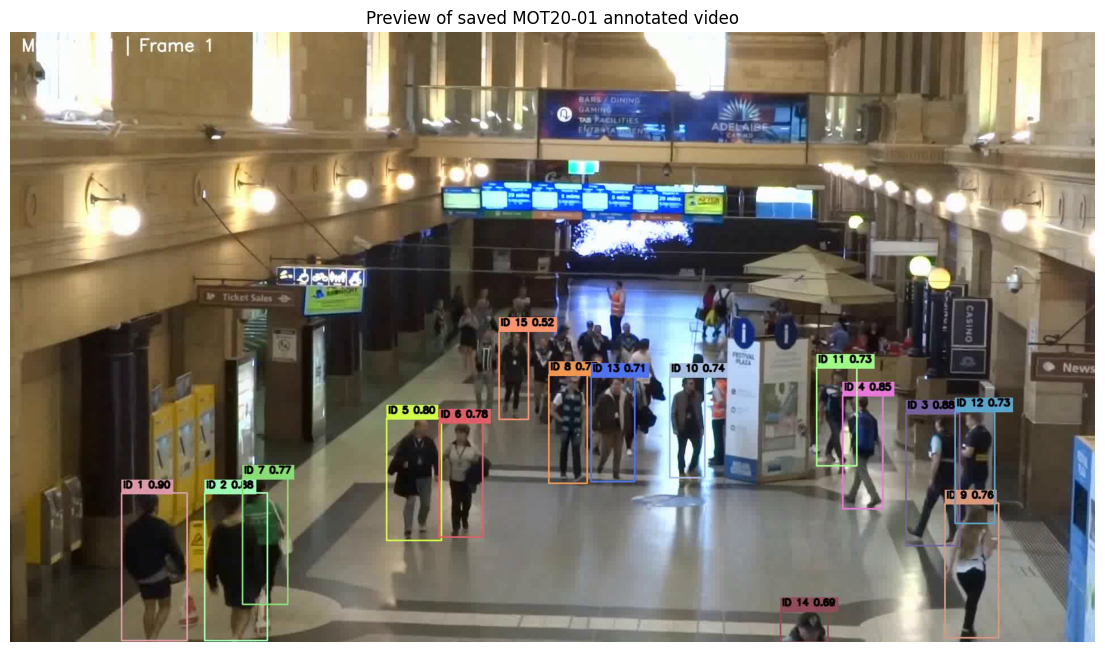

In [46]:
cap = cv2.VideoCapture(str(video_path))
ok, frame = cap.read()
cap.release()

if ok:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Preview of saved MOT20-01 annotated video")
    plt.show()
else:
    print("Could not read preview frame from:", video_path)

In [47]:
import shutil

archive_path = shutil.make_archive(str(OUT_DIR), "zip", str(OUT_DIR))
print("Saved archive:", archive_path)

Saved archive: /kaggle/working/mot20_01_botsort_transreid_video.zip


In [ ]:
import shutil
import os
from IPython.display import FileLink

# 1. Define the name of your output zip file (without the .zip extension)
archive_name = 'working_folder_download'

# 2. Compress the /kaggle/working directory
shutil.make_archive(archive_name, 'zip', '/kaggle/working')

# 3. Create a clickable link to download the zip file
os.chdir('/kaggle/working')
FileLink(f'{archive_name}.zip')